In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
titanic=sns.load_dataset('titanic')

In [4]:
titanic. groupby(['sex', 'pclass'])['survived'].mean()*100

sex     pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

In [5]:
titanic.groupby(['sex', 'pclass'])[['survived', 'age']].agg(['mean'])

survived        age
                   mean       mean
sex    pclass                     
female 1       0.968085  34.611765
       2       0.921053  28.722973
       3       0.500000  21.750000
male   1       0.368852  41.281386
       2       0.157407  30.740707
       3       0.135447  26.507589

In [6]:
titanic.groupby(['pclass', 'embarked'])['survived'].mean()

pclass  embarked
1       C           0.694118
        Q           0.500000
        S           0.582677
2       C           0.529412
        Q           0.666667
        S           0.463415
3       C           0.378788
        Q           0.375000
        S           0.189802
Name: survived, dtype: float64

In [7]:
titanic.groupby('pclass')[['survived', 'fare']].agg(['mean'])*100

,survived,fare
,mean,mean
pclass,,
1,62.962963,8415.468750
2,47.282609,2066.218315
3,24.236253,1367.555010


In [8]:
titanic.groupby('sex')[['age', 'survived']].agg(['mean'])

,age,survived
,mean,mean
sex,,
female,27.915709,0.742038
male,30.726645,0.188908


In [9]:
titanic['familysize']=titanic['sibsp']+titanic['parch']+1

In [10]:
titanic.groupby(['sex'])[['survived', 'familysize']].agg(['mean'])

,survived,familysize
,mean,mean
sex,,
female,0.742038,2.343949
male,0.188908,1.665511


In [11]:
titanic['alone']

0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: alone, Length: 891, dtype: bool

In [15]:
titanic['IsAlone'] = (titanic['sibsp']+titanic['parch']==0).astype(int)

In [18]:
titanic['fare_category'] = pd.qcut(titanic['fare'], q=4, labels=['Low', 'Medium', 'High', 'Luxury'])
titanic['fare_category'] 

0         Low
1      Luxury
2      Medium
3      Luxury
4      Medium
        ...  
886    Medium
887      High
888      High
889      High
890       Low
Name: fare_category, Length: 891, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Luxury']

In [23]:
bins=[0, 1, 4, 6, float('inf')]
labels=['Alone', 'Small', 'Medium', 'Large']

titanic['family_category'] = pd.cut(titanic['familysize'], bins=bins, labels=labels)
titanic['family_category'].value_counts()

family_category
Alone     537
Small     292
Medium     37
Large      25
Name: count, dtype: int64

<Axes: xlabel='fare'>

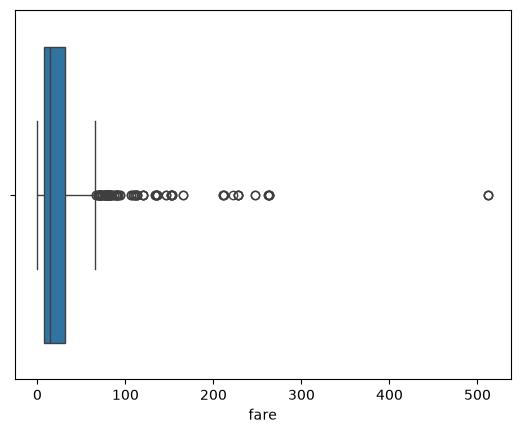

In [24]:
sns.boxplot(x='fare', data=titanic)

In [29]:
age_bins=[0, 9, 12, 35, 60]
age_labels=['child', 'Young Adult', 'Adult', "Senior"]
titanic['age_group']= pd.cut(titanic['age'], bins=age_bins, labels=age_labels)

<Axes: xlabel='age_group', ylabel='survived'>

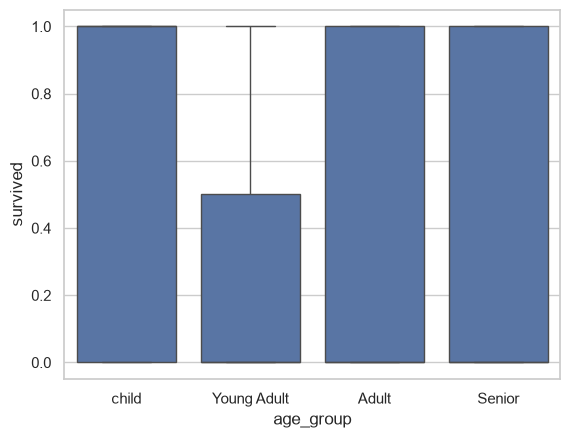

In [30]:
sns.boxplot(x='age_group', y='survived', data=titanic)